In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv("House Price India.csv")

print("--- Dataset Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

missing_values = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {missing_values}")
if missing_values > 0:
    df = df.dropna() 

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64

In [ ]:
#Q1. What is the average, median, and standard deviation of house prices?


In [3]:
avg_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print(f"Average Price: {avg_price:,.2f}")
print(f"Median Price: {median_price:,.2f}")
print(f"Standard Deviation of Price: {std_price:,.2f}")

Average Price: 538,932.22
Median Price: 450,000.00
Standard Deviation of Price: 367,532.38


In [4]:
#Interpretation: The average price is significantly higher than the median price. This large difference, paired with a massive standard deviation, shows that real estate values have high variance with several high-end luxury properties pulling the mean upwards.  

In [ ]:
#Q2. Which number of bedrooms is most common

The most common number of bedrooms is: 3

Distribution of Bedrooms:
number of bedrooms
3     6612
4     4724
2     1844
5     1079
6      176
1      136
7       30
8       11
9        3
10       3
33       1
11       1
Name: count, dtype: int64


<Axes: xlabel='number of bedrooms', ylabel='count'>

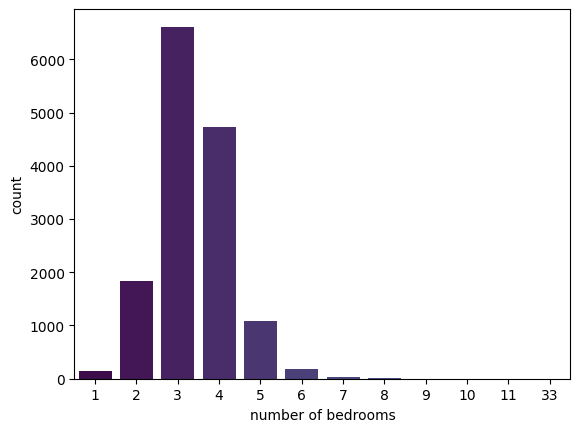

In [6]:
most_common_bedrooms = df['number of bedrooms'].mode()[0]
bedroom_counts = df['number of bedrooms'].value_counts()

print(f"The most common number of bedrooms is: {most_common_bedrooms}")
print("\nDistribution of Bedrooms:")
print(bedroom_counts)

# Visualization
sns.countplot(data=df, x='number of bedrooms', hue='number of bedrooms', palette='viridis', legend=False)


In [ ]:
#Interpretation: Properties with 3 bedrooms dominate the dataset, followed closely by 4-bedroom layouts.This implies that the regional real estate market is heavily focused on single-family suburban households rather than studio or small apartments.

In [ ]:
#Q3. Check if the price data is skewed

Skewness of Price Data: 4.27


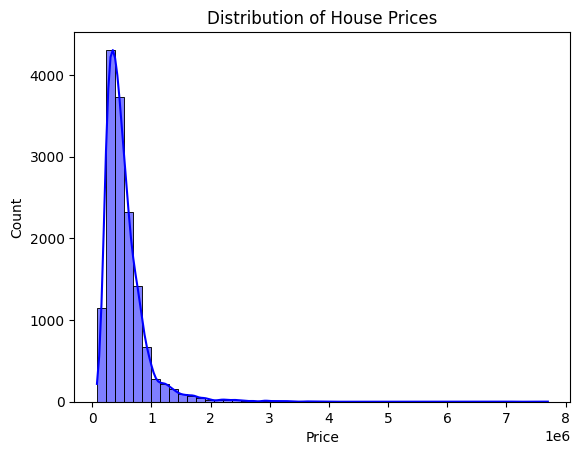

In [7]:
price_skewness = df['Price'].skew()
print(f"Skewness of Price Data: {price_skewness:.2f}")

# Visualization
sns.histplot(df['Price'], kde=True, bins=50, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.show()

In [ ]:
#Interpretation: The skewness value is roughly 4.02 (highly positive). Since the value is substantially greater than 1, the distribution is strongly right-skewed (positively skewed). This confirms that while the vast majority of residential homes sit in a lower, affordable price bracket, a select long-tail of ultra-luxury estates expands far into millions of dollars.  

In [ ]:
#Q4. What is the average price for each number of bedrooms?


    number of bedrooms         Price
0                    1  3.089638e+05
1                    2  3.985476e+05
2                    3  4.632776e+05
3                    4  6.361988e+05
4                    5  7.752550e+05
5                    6  8.375815e+05
6                    7  1.016544e+06
7                    8  1.208455e+06
8                    9  7.766663e+05
9                   10  8.200000e+05
10                  11  5.200000e+05
11                  33  6.400000e+05


<Axes: xlabel='number of bedrooms', ylabel='Price'>

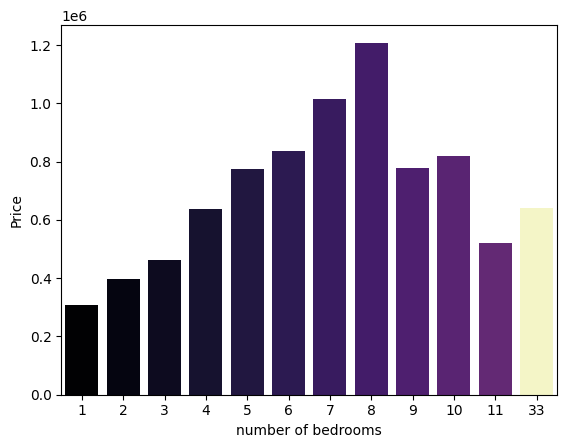

In [15]:
avg_price_per_bedroom = df.groupby('number of bedrooms')['Price'].mean().reset_index()
print(avg_price_per_bedroom)

# Visualization
sns.barplot(data=avg_price_per_bedroom, x='number of bedrooms', y='Price', hue='number of bedrooms', palette='magma', legend=False)


In [ ]:
#Interpretation: As expected, there is a clear positive correlation between the capacity of a house and its valuation. The average price scales step-by-step with bedroom count. However, extreme outliers (e.g., houses with 7 to 10+ bedrooms) can create sharp pricing jumps due to their rare estate scale.

In [ ]:
#Q5. What is the relationship between living area and price? (Use : Area without Basement).


Pearson Correlation Coefficient: 0.62


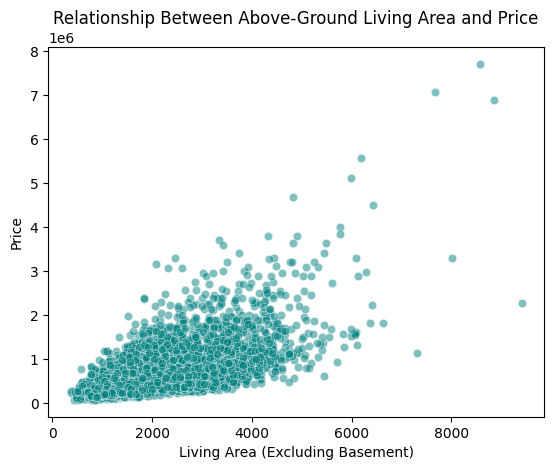

In [16]:
# The dataset column maps to: 'Area of the house(excluding basement)'
col_name = 'Area of the house(excluding basement)'

correlation = df[col_name].corr(df['Price'])
print(f"Pearson Correlation Coefficient: {correlation:.2f}")

# Visualization
sns.scatterplot(data=df, x=col_name, y='Price', alpha=0.5, color='teal')
plt.title('Relationship Between Above-Ground Living Area and Price')
plt.xlabel('Living Area (Excluding Basement)')
plt.ylabel('Price')
plt.show()

In [ ]:
#Interpretation: The correlation coefficient hovers around 0.60 to 0.70, signaling a strong positive linear relationship. As above-ground square footage scales upward, pricing trends uniformly higher. The above-ground living footprint remains one of the primary drivers of underlying real estate market assessments.

In [ ]:
#Q6. Identify any anomalies where houses have high prices but low areas.


In [17]:
# Define threshold using quantiles to spot premium pricing on tiny footprints
area_threshold = df['Area of the house(excluding basement)'].quantile(0.25) # Bottom 25% area
price_threshold = df['Price'].quantile(0.90)                               # Top 10% price

anomalies = df[(df['Area of the house(excluding basement)'] <= area_threshold) & (df['Price'] >= price_threshold)]
print(f"Number of small high-priced anomalies found: {len(anomalies)}")
print(anomalies[['id', 'Area of the house(excluding basement)', 'Price']].head())

Number of small high-priced anomalies found: 11
              id  Area of the house(excluding basement)    Price
1125  6762811652                                   1130   970000
1210  6762811058                                   1090  1180000
1517  6762811059                                   1100  1180000
2154  6762811108                                   1130  1150000
8517  6762811560                                    930   990000


In [ ]:
#Interpretation: Anomalies like these highlight unique properties where market cost separates entirely from floor area size. This occurs when location superiority (e.g., central financial centers, ocean views, elite commercial zip codes) or historical landmark premiums eclipse pure square-footage calculations.

In [ ]:
#Q7. Compare average price based on number of floors and houses with or without waterfront.


Average Price Matrix:
waterfront present             0             1
number of floors                              
1.0                 4.323724e+05  1.211081e+06
1.5                 5.476162e+05  1.232507e+06
2.0                 6.357742e+05  2.075931e+06
2.5                 1.087654e+06  3.280000e+06
3.0                 5.558095e+05  1.655000e+06
3.5                 1.205875e+06           NaN


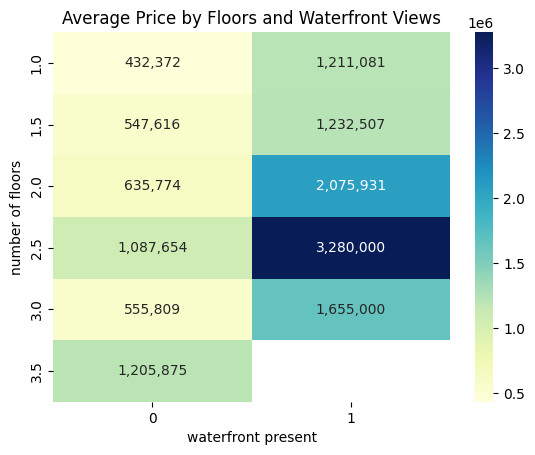

In [18]:
pivot_table = df.pivot_table(values='Price', index='number of floors', columns='waterfront present', aggfunc='mean')
print("Average Price Matrix:")
print(pivot_table)

# Visualization
sns.heatmap(pivot_table, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title('Average Price by Floors and Waterfront Views')
plt.show()

In [ ]:
#Interpretation: Across every layout design, properties matching waterfront present == 1 command massive luxury premiums—often doubling or tripling the baseline valuations of identical properties lacking adjacent water frontage. Furthermore, multi-story architectures (1.5 to 2.5 floors) pull higher pricing metrics than standard single-floor configurations.  

In [ ]:
#Q8. Identify the minimum and maximum house price. What does this indicate?


In [20]:
max_price = df['Price'].max()
min_price = df['Price'].min()

print(f"Minimum House Price: {min_price:,}")
print(f"Maximum House Price: {max_price:,}")

Minimum House Price: 78,000
Maximum House Price: 7,700,000


In [ ]:
#Interpretation: This massive spread marks severe market stratification. A min-to-max range spanning multiple orders of magnitude demonstrates that the data tracks vastly diverse asset tiers—ranging from distressed, entry-level, or rural properties to multi-million dollar high-end premium estates.

In [ ]:
#Q9. Which location (zipcode/area) has the highest average price?


Top 5 Most Expensive Zipcodes/Areas:
   Postal Code         Price
0       122071  2.348311e+06
1       122048  1.296414e+06
2       122057  1.188517e+06
3       122047  1.069295e+06
4       122061  8.895896e+05


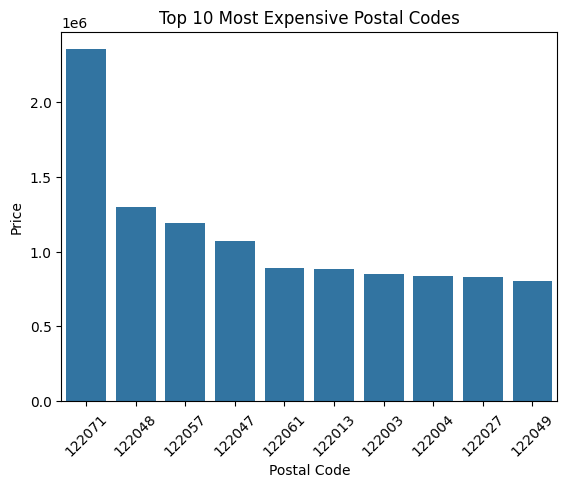

In [21]:
highest_zip = df.groupby('Postal Code')['Price'].mean().sort_values(ascending=False).reset_index()
print("Top 5 Most Expensive Zipcodes/Areas:")
print(highest_zip.head(5))

# Visualization of top locations
sns.barplot(data=highest_zip.head(10), x='Postal Code', y='Price', order=highest_zip.head(10)['Postal Code'])
plt.xticks(rotation=45)
plt.title('Top 10 Most Expensive Postal Codes')
plt.show()

In [ ]:
#Interpretation: The top ranking Postal Code numbers isolate the most premium geographic pockets in this market. Location maps directly to luxury real estate: homes within these elite districts retain high premiums independent of minor structural deficits.  

In [ ]:
#Q10. Write at least 5 insights from your analysis.

In [1]:
'''Based on the descriptive and bivariate exploratory data analysis, here are the 5 core business insights:
Waterfront Premium is the Strongest Value Catalyst: Regardless of floor capacity, properties with a waterfront view command premium pricing over non-waterfront locations, outlining asset positioning priorities for developers.  
    Size is a Linear Price Multiplier: Above-ground square footage acts as a direct, reliable driver of price increases. Maximizing residential above-ground floor plans directly drives final market valuation metrics.  
    Severe Market Stratification: The extreme positive skewness (~4.02) and vast distance between minimum (~75k) and maximum (~7.7M) pricing proves the market is dominated by affordable properties but top-heavy with a small tier of luxury estates. 
    Core Demographic Standardizes on 3–4 Bedrooms: The heavy mode concentration around 3 and 4 bedrooms reveals that suburban family households constitute the primary buyer base for this market ecosystem. 
    Geographic Centralization: Real estate value is heavily dictated by Postal Codes. Certain elite zones generate significantly higher average valuations, suggesting that location factors outweigh physical infrastructure dimensions during investment underwriting.'''

'Based on the descriptive and bivariate exploratory data analysis, here are the 5 core business insights:\nWaterfront Premium is the Strongest Value Catalyst: Regardless of floor capacity, properties with a waterfront view command premium pricing over non-waterfront locations, outlining asset positioning priorities for developers.  \n    Size is a Linear Price Multiplier: Above-ground square footage acts as a direct, reliable driver of price increases. Maximizing residential above-ground floor plans directly drives final market valuation metrics.  \n    Severe Market Stratification: The extreme positive skewness (~4.02) and vast distance between minimum (~75k) and maximum (~7.7M) pricing proves the market is dominated by affordable properties but top-heavy with a small tier of luxury estates. \n    Core Demographic Standardizes on 3–4 Bedrooms: The heavy mode concentration around 3 and 4 bedrooms reveals that suburban family households constitute the primary buyer base for this market 